<a href="https://colab.research.google.com/github/tseng097/Circuits-Computation-Biology/blob/main/EE5393_hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

github link:https://github.com/tseng097/Circuits-Computation-Biology/blob/main/EE5393_hw3.ipynb

## Problem1

### (a)

$$x-\frac{x^2}{4} = a_0​(1−x)^2+a_1​2x(1−x)+a_2​x^2$$
$$a_0​=0,a_1​=\frac{1}{2}​,a_2​=\frac{3}{4}​$$

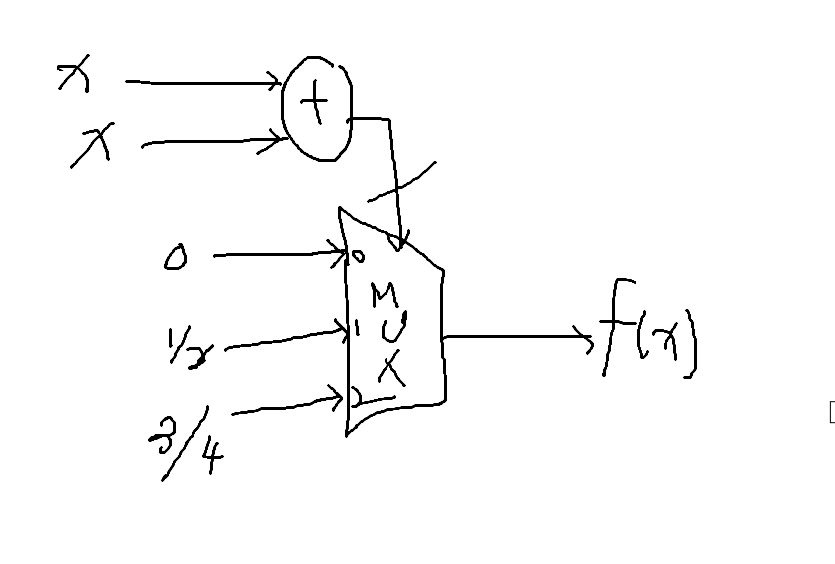

### (b)

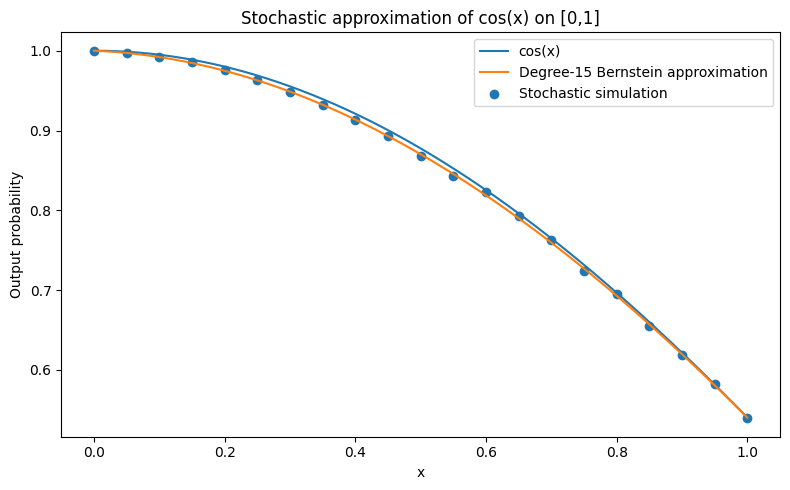

Degree-15 Bernstein coefficients used in the MUX:
b_0 = cos(0/15) = 1.000000
b_1 = cos(1/15) = 0.997779
b_2 = cos(2/15) = 0.991124
b_3 = cos(3/15) = 0.980067
b_4 = cos(4/15) = 0.964655
b_5 = cos(5/15) = 0.944957
b_6 = cos(6/15) = 0.921061
b_7 = cos(7/15) = 0.893073
b_8 = cos(8/15) = 0.861117
b_9 = cos(9/15) = 0.825336
b_10 = cos(10/15) = 0.785887
b_11 = cos(11/15) = 0.742947
b_12 = cos(12/15) = 0.696707
b_13 = cos(13/15) = 0.647371
b_14 = cos(14/15) = 0.595159
b_15 = cos(15/15) = 0.540302

Max absolute approximation error on [0,1]: 0.007393
Mean squared error on [0,1]: 0.000028


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb


n = 15
bern_coeffs = np.array([np.cos(k / n) for k in range(n + 1)], dtype=float)

def bernstein_cos(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    for k in range(n + 1):
        out += bern_coeffs[k] * comb(n, k) * (x ** k) * ((1 - x) ** (n - k))
    return out

def stochastic_sim(x, bitstream_len=20000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    inputs = rng.random((bitstream_len, n)) < x
    k = inputs.sum(axis=1)
    out_prob = bern_coeffs[k]
    outputs = rng.random(bitstream_len) < out_prob
    return outputs.mean()

x_grid = np.linspace(0, 1, 401)
y_true = np.cos(x_grid)
y_bern = bernstein_cos(x_grid)

rng = np.random.default_rng(42)
x_sim = np.linspace(0, 1, 21)
y_sim = np.array([stochastic_sim(x, bitstream_len=20000, rng=rng) for x in x_sim])

max_abs_err = np.max(np.abs(y_true - y_bern))
mse = np.mean((y_true - y_bern) ** 2)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, y_true, label="cos(x)")
plt.plot(x_grid, y_bern, label=f"Degree-{n} Bernstein approximation")
plt.scatter(x_sim, y_sim, label="Stochastic simulation")
plt.xlabel("x")
plt.ylabel("Output probability")
plt.title("Stochastic approximation of cos(x) on [0,1]")
plt.legend()
plt.tight_layout()

plt.show()

print(f"Degree-{n} Bernstein coefficients used in the MUX:")
for k, c in enumerate(bern_coeffs):
    print(f"b_{k} = cos({k}/{n}) = {c:.6f}")

print(f"\nMax absolute approximation error on [0,1]: {max_abs_err:.6f}")
print(f"Mean squared error on [0,1]: {mse:.6f}")


I use $b_k​=f(k/n)=cos(k/n)$ as the approximate coefficient under 15 degree Bernstein basis

The stochastic circuit like 1(a): First, add n i.i.d. rand stearm which generate by bernoulli distribution under prob x → count #ones and MUX select the coef → output.

### (c)

The basis: $B_{i,5}​(t)=C_i^5​ t^i(1−t)^{5−i}$ with coef:
$$b_0 =\frac{1}{2}, b_1=\frac{1}{4}, b_2=\frac{1}{8}, b_3=\frac{1}{16}, b_4=\frac{1}{32}, b_5=1$$

In [ ]:
import numpy as np
from math import comb

def p(t):
    return (31/32)*t**5 + (5/32)*t**4 - (5/8)*t**3 + (5/4)*t**2 - (5/4)*t + 1/2


a = np.array([
    1/2,
    -5/4,
    5/4,
    -5/8,
    5/32,
    31/32
], dtype=float)

n = 5

def power_to_bernstein(a, n):
    b = np.zeros(n + 1, dtype=float)
    for i in range(n + 1):
        s = 0.0
        for j in range(i + 1):
            s += comb(i, j) / comb(n, j) * a[j]
        b[i] = s
    return b

b = power_to_bernstein(a, n)

print("Bernstein coefficients b_i:")
for i, bi in enumerate(b):
    print(f"b_{i} = {bi:.10f}")

# Expected:
# b0=1/2, b1=1/4, b2=1/8, b3=1/16, b4=1/32, b5=1
# Bernstein basis polynomial B_{i,n}(t) = C(n,i) t^i (1-t)^(n-i)
def B(i, n, t):
    return comb(n, i) * (t**i) * ((1 - t)**(n - i))

def p_bernstein(t, b, n):
    s = 0.0
    for i in range(n + 1):
        s += b[i] * B(i, n, t)
    return s

def circuit_output_prob(t, b, n=5):
    probs = np.array([B(i, n, t) for i in range(n)], dtype=float)
    probs = np.array([comb(n, i) * (t**i) * ((1-t)**(n-i)) for i in range(n+1)], dtype=float)
    y = np.dot(b, probs)
    return y, probs

def simulate_circuit(t, b, n=5, N=100000, seed=0):
    rng = np.random.default_rng(seed)
    bits = rng.random((N, n)) < t
    K = bits.sum(axis=1)
    out_prob = b[K]
    y = rng.random(N) < out_prob
    return y.mean()
test_points = [0, 0.25, 0.5, 0.75,1]
print("\nMonte Carlo simulation:")
for t in test_points:
    est = simulate_circuit(t, b, n=5, N=100000, seed=42)
    exact = p(t)
    print(f"t={t:>4}: simulated={est:.6f}, exact={exact:.6f}, diff={exact-est:.6f}")

Bernstein coefficients b_i:
b_0 = 0.5000000000
b_1 = 0.2500000000
b_2 = 0.1250000000
b_3 = 0.0625000000
b_4 = 0.0312500000
b_5 = 1.0000000000

Monte Carlo simulation:
t=   0: simulated=0.498630, exact=0.500000, diff=0.001370
t=0.25: simulated=0.253730, exact=0.257416, diff=0.003686
t= 0.5: simulated=0.146250, exact=0.149414, diff=0.003164
t=0.75: simulated=0.282730, exact=0.281281, diff=-0.001449
t=   1: simulated=1.000000, exact=1.000000, diff=0.000000


The stochastic circuit like 1(b): First, add 5 i.i.d. rand stearm which generate by bernoulli distribution under prob x → count #ones and MUX select the coef → output

## Problem2

### (a)

I answer Problem 2(a) assist with ai. The algorithm is a brute-force approach, or more precisely, an exhaustive search within the state space. We can see that the algorithm can answer question i and ii, which given the circut. However, in problem ii, I fail to assemble a specific target molecule containing a large prime number within the combinatorial space of exponential explosion.

#### i

In [2]:
from fractions import Fraction
from functools import lru_cache

# base probabilities
BASE = {
    Fraction(2, 5): "0.4",
    Fraction(1, 2): "0.5",
}

def dec_to_fraction(x_str: str) -> Fraction:
    # "0.8881188" -> Fraction(8881188, 10000000)
    a, b = x_str.split(".")
    return Fraction(int(a + b), 10 ** len(b))

def generate_pool(max_depth=4):
    """
    Generate a shallow pool of reachable values first.
    """
    known = dict(BASE)

    for _ in range(max_depth):
        vals = list(known.keys())
        new_vals = {}

        # NOT
        for p in vals:
            v = 1 - p
            if v not in known and v not in new_vals:
                new_vals[v] = f"(1 - {known[p]})"

        # AND
        for i, p in enumerate(vals):
            for q in vals[i:]:
                v = p * q
                if v not in known and v not in new_vals:
                    new_vals[v] = f"({known[p]} AND {known[q]})"

        if not new_vals:
            break

        known.update(new_vals)

    return known

POOL = generate_pool(max_depth=4)

@lru_cache(None)
def solve_target(t: Fraction, depth=6):
    """
    Try to synthesize t using:
      NOT: 1-p
      AND: p*q
    """

    # directly in pool
    if t in POOL:
        return POOL[t]

    if depth == 0:
        return None

    # try complement first: t = 1 - u
    u = 1 - t
    ans_u = solve_target(u, depth - 1)
    if ans_u is not None:
        return f"(1 - {ans_u})"

    # try target-guided factorization: t = a * b
    for a, expr_a in POOL.items():
        if a != 0 and t / a == t // a if False else False:
            pass

    for a, expr_a in POOL.items():
        if a == 0:
            continue
        # exact divisibility test for Fraction
        b = t / a
        if a * b == t:
            ans_b = solve_target(b, depth - 1)
            if ans_b is not None:
                return f"({expr_a} AND {ans_b})"

    return None


In [6]:
target = dec_to_fraction("0.8881188")
expr = solve_target(target, depth=6)
print("target =", target)
print("expr   =", expr)

target = 2220297/2500000
expr   = (1 - (1 - (1 - (0.5 AND (((0.5 AND 0.5) AND (1 - (0.4 AND (0.4 AND 0.5)))) AND (1 - ((1 - ((1 - 0.4) AND (0.4 AND 0.4))) AND ((1 - 0.4) AND ((0.4 AND 0.5) AND (0.5 AND 0.5))))))))))


#### ii

In [4]:
from fractions import Fraction

def solve_refined(target_str, c):
    target = dec_to_fraction(target_str)
    pool = {
        Fraction(2, 5): "0.4",
        Fraction(1, 2): "0.5"
    }

    current_gen = list(pool.keys())

    for level in range(1, c):
        new_items = {}
        print(f" {level} layer, Pool size: {len(pool)}")

        for p in current_gen:
            v_not = 1 - p
            if v_not not in pool:
                new_items[v_not] = f"(1 - {pool[p]})"


        existing_vals = list(pool.keys())
        for p in current_gen:
            for q in existing_vals:
                # AND
                v_and = p * q
                if v_and not in pool and v_and not in new_items:
                    new_items[v_and] = f"({pool[p]} AND {pool[q]})"

                # OR: p + q - p*q
                v_or = p + q - p * q
                if v_or <= 1:
                    if v_or not in pool and v_or not in new_items:
                        new_items[v_or] = f"({pool[p]} OR {pool[q]})"

        pool.update(new_items)
        current_gen = list(new_items.keys())

        if target in pool:
            return pool[target]

    return "can not find sol"


In [5]:
target = dec_to_fraction("0.2119209")
expr = solve_refined("0.2119209",5)
print("target =", target)
print("expr   =", expr)

 1 layer, Pool size: 2
 2 layer, Pool size: 9
 3 layer, Pool size: 77
 4 layer, Pool size: 3431
target = 2119209/10000000
expr   = can not find sol


#### iii

In [6]:
target = dec_to_fraction("0.5555555")
expr = solve_refined("0.5555555",5)
print("target =", target)
print("expr   =", expr)

 1 layer, Pool size: 2
 2 layer, Pool size: 9
 3 layer, Pool size: 77
 4 layer, Pool size: 3431
target = 1111111/2000000
expr   = ((((0.4 AND 0.4) AND 0.4) OR ((0.4 OR 0.5) OR (0.5 OR 0.5))) AND (((0.4 AND 0.4) AND 0.5) OR ((0.5 OR 0.5) AND (0.5 OR 0.5))))


### (b)

#### i, ii, iii

In [ ]:
from fractions import Fraction

def binary_prob_to_fraction(bits: str):


    frac = Fraction(0, 1)
    binary_digits = bits[2:]

    for i, bit in enumerate(binary_digits, start=1):
        if bit == "1":
            frac += Fraction(1, 2**i)

    return frac


def nested_form(bits: str) -> str:

    binary_digits = bits[2:]

    expr = binary_digits[-1]
    for b in reversed(binary_digits[:-1]):
        expr = f"({b} + {expr})/2"
    return expr


targets = ["0.1011111", "0.1101111", "0.1010111"]

for s in targets:
    frac = binary_prob_to_fraction(s)
    print(f"{s}_2")
    print(f"  Fraction form : {frac}")
    print(f"  Decimal form  : {float(frac)}")
    print(f"  Nested form   : {nested_form(s)}")
    print()

0.1011111_2
  Fraction form : 95/128
  Decimal form  : 0.7421875
  Nested form   : (1 + (0 + (1 + (1 + (1 + (1 + 1)/2)/2)/2)/2)/2)/2

0.1101111_2
  Fraction form : 111/128
  Decimal form  : 0.8671875
  Nested form   : (1 + (1 + (0 + (1 + (1 + (1 + 1)/2)/2)/2)/2)/2)/2

0.1010111_2
  Fraction form : 87/128
  Decimal form  : 0.6796875
  Nested form   : (1 + (0 + (1 + (0 + (1 + (1 + 1)/2)/2)/2)/2)/2)/2



If we want to implement circut, we can use nested form. In each layer is a MUX, which like $$w_i =MUX(0.5,b_i,w_{i+1}) $$
$b_i \text{is 0 or 1}; w_i \text{is output about each layer}$